In [27]:
import folium

In [28]:
#23.1
import folium
m = folium.Map(location=[10.761502, 106.669527], zoom_start=14)

folium.Marker([10.761502, 106.669527], popup="UEH Cơ sở B", tooltip="Click vào").add_to(m)
folium.Marker([10.762512, 106.666270], popup="Bệnh viện Nhi Đồng 1", tooltip="Click vào").add_to(m)
folium.Marker([10.771217, 106.668853], popup="Vạn Hạnh Mall", tooltip="Click vào").add_to(m)
folium.Marker([10.771618, 106.664275], popup="UBND Quận 10", tooltip="Click vào").add_to(m)
folium.Marker([10.750541, 106.653284], popup="Bến xe Chợ Lớn", tooltip="Click vào").add_to(m)
folium.Marker([10.766348, 106.657512], popup="Nhà Thi Đấu Phú Thọ", tooltip="Click vào").add_to(m)
m

In [29]:
#23.2
from geopy.distance import geodesic
import folium

m = folium.Map(location=[12.24055077703633, 109.19692249597601], zoom_start=14)
center = (12.24055077703633, 109.19692249597601)
center_name = "Trung tâm thành phố Nha Trang"

location_data = [
    ("Tháp Bà Ponagar", [12.265597134594938, 109.19539998248388]),
    ("Hòn Chồng", [12.274558808823103, 109.20002095364823]),
    ("Trường THPT Lý Tự Trọng", [12.247562611754164, 109.19326669782683]),
    ("Chợ Đầm", [12.255119137630997, 109.19175202296142]),
    ("Viện Hải Dương Học", [12.207847053911104, 109.21453751131878]),
    ("Vinpearl", [12.226541239993908, 109.23705686888187]),
    ("Trường THPT Chuyên Lê Quý Đôn", [12.1967032280635, 109.17368935364705]),
    ("Bệnh viện Quân y ", [12.231720540636738, 109.19487258536911]),
    ("Sân vận động 19-8 Nha Trang", [12.250578709594595, 109.19298612481207]),
    ("Ga Nha Trang", [12.24867219218095, 109.18417252687722])
]
folium.Marker(center, popup=center_name, tooltip="Trung tâm thành phố Nha Trang", color = 'red').add_to(m)
for name, coord in location_data:
    dist = geodesic(center, coord).km
    folium.Marker(coord, popup=f"{name} - Cách tâm: {dist:.2f} km", tooltip="Click vào").add_to(m)
    folium.PolyLine(locations=[center, coord], color="blue").add_to(m)
m

In [30]:
#23.3
import folium
from geopy.geocoders import Nominatim
import folium
from folium.plugins import HeatMap
import numpy as np
import pandas as pd
geolocator = Nominatim(user_agent="my_mapping_app_123",timeout = 10)
center = geolocator.geocode("Đại học Kinh tế TP.HCM, Hồ Chí Minh")
center_lat, center_lon = center.latitude, center.longitude

lats = center_lat + np.random.normal(0, 0.005, 100)
lons = center_lon + np.random.normal(0, 0.005, 100)
df_orders = pd.DataFrame({'lat': lats, 'lon': lons})
heat_data = [[row['lat'], row['lon']] for index, row in df_orders.iterrows()]


m = folium.Map([center_lat, center_lon], tiles='CartoDB positron')

HeatMap(data=heat_data, radius = 20).add_to(m)

m

In [49]:
#23.4
import geopandas as gpd
import pandas as pd
import folium
import numpy as np

gdf = gpd.read_file("/content/district-boundary-hcm-city.geojson")
df = pd.read_csv("/content/hcm_district_data(1).csv")

geo = gdf.__geo_interface__
for feature in geo["features"]:
    feature.pop("timestamp", None)
    feature["properties"].pop("timestamp", None)

    for key, value in feature["properties"].items():
        if isinstance(value, np.ndarray):
            feature["properties"][key] = value.tolist()

m = folium.Map(location=[10.78, 106.68], zoom_start=11)

folium.Choropleth(
    geo_data=geo,
    data=df,
    columns=["district", "sales"],
    key_on="feature.properties.localname",
    fill_color="YlOrRd",
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name="Doanh số"
).add_to(m)

m

In [32]:
#23.5
import folium
from geopy.distance import geodesic

warehouse = (10.7758, 106.7009)
customers = [
    ("KH1", (10.762, 106.682)),
    ("KH2", (10.751, 106.674)),
    ("KH3", (10.800, 106.720)),
    ("KH4", (10.730, 106.650))
]

m = folium.Map(location=warehouse, zoom_start=13)
folium.Circle(warehouse, radius=3000, color='green', fill=True).add_to(m)
folium.Circle(warehouse, radius=5000, color='orange', fill=True).add_to(m)
folium.Circle(warehouse, radius=10000, color='red', fill=True).add_to(m)

for name, coord in customers:
    dist = geodesic(warehouse, coord).km

    if dist <= 3:
        status = "Gần (rất tốt)"
        color = "green"
    elif dist <= 5:
        status = "Trung bình"
        color = "orange"
    elif dist <= 10:
        status = "Xa"
        color = "red"
    else:
        status = "Quá xa"
        color = "black"

    folium.Marker(coord,popup=f"{name}: {dist:.2f} km - {status}",).add_to(m)

m

In [33]:
pip install osmnx

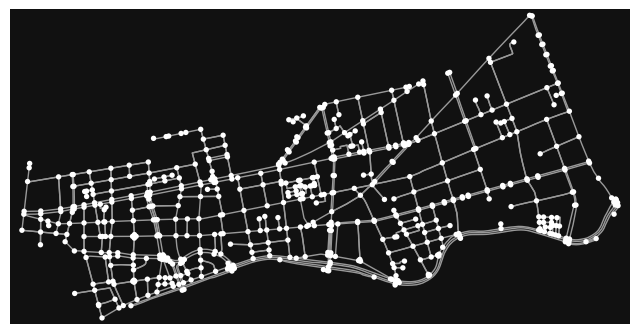

Số nút giao: 586
Số đoạn đường: 1311
Chiều dài trung bình (m): 82.92
Mật độ mạng (km/km²): 306945051301.46


/tmp/ipykernel_2730/2705829825.py:17: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  area = ox.geocode_to_gdf(place).geometry.area.iloc[0]


In [34]:
#23.6
import osmnx as ox
import networkx as nx


place = "District 5, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(place, network_type='drive')
ox.plot_graph(G)


num_nodes = len(G.nodes)
num_edges = len(G.edges)
total_length = sum(data['length'] for u, v, data in G.edges(data=True))
avg_length = total_length / num_edges


area = ox.geocode_to_gdf(place).geometry.area.iloc[0]
density = (total_length / 1000) / (area / 1e6)
print("Số nút giao:", num_nodes)
print("Số đoạn đường:", num_edges)
print("Chiều dài trung bình (m):", round(avg_length, 2))
print("Mật độ mạng (km/km²):", round(density, 2))

In [35]:
pip install osmnx networkx folium

In [36]:
#23.7
import osmnx as ox
import networkx as nx
import folium


place = "Nha Trang, Khanh Hoa, Vietnam"
G = ox.graph_from_place(place, network_type='drive')

point_a = (12.247604550346686, 109.19314868063283)
point_b = (12.198132953734103, 109.17359499742322)

orig = ox.distance.nearest_nodes(G, point_a[1], point_a[0])
dest = ox.distance.nearest_nodes(G, point_b[1], point_b[0])


route_dijkstra = nx.shortest_path(G, orig, dest, weight='length')


def heuristic(u, v):
    x1, y1 = G.nodes[u]['x'], G.nodes[u]['y']
    x2, y2 = G.nodes[v]['x'], G.nodes[v]['y']
    return ((x1 - x2)**2 + (y1 - y2)**2)**0.5

route_astar = nx.astar_path(G, orig, dest, heuristic=heuristic, weight='length')
m = folium.Map(location=point_a, zoom_start=13)
def add_route(map_obj, route, color):
    coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in route]
    folium.PolyLine(coords, color=color, weight=5).add_to(map_obj)

add_route(m, route_dijkstra, "blue")
add_route(m, route_astar, "red")

folium.Marker(point_a, popup="Start").add_to(m)
folium.Marker(point_b, popup="End").add_to(m)

m

In [37]:
#23.8
from geopy.distance import geodesic
import pandas as pd
import folium
drivers = {
    "Tài xế 1": (21.0285, 105.8542),
    "Tài xế 2": (21.0368, 105.8342),
    "Tài xế 3": (21.0543, 105.8210)
}

customers = {
    "Khách 1": (21.0280, 105.7640),
    "Khách 2": (21.0054, 105.8430),
    "Khách 3": (21.0287, 105.8990)
}

m = folium.Map(location=[10.775, 106.700], zoom_start=15)

for name, coord in drivers.items():
    folium.Marker(
        coord,
        popup=name,
        icon=folium.Icon(color="green", icon="car")
    ).add_to(m)

for name, coord in customers.items():
    folium.Marker(
        coord,
        popup=name,
        icon=folium.Icon(color="red", icon="user")
    ).add_to(m)

matches = []
used_drivers = set()

colors = ["yellow "]
i = 0

for c_name, c_coord in customers.items():
    best_driver = None
    best_dist = 10**9

    for d_name, d_coord in drivers.items():
        if d_name in used_drivers:
            continue

        dist = geodesic(c_coord, d_coord).km

        if dist < best_dist:
            best_dist = dist
            best_driver = d_name

    if best_driver:
        used_drivers.add(best_driver)
        matches.append([c_name, best_driver, round(best_dist, 2)])

        folium.PolyLine(
            [customers[c_name], drivers[best_driver]],
            color=colors[i % len(colors)],
            weight=4,
            popup=f"{c_name} ↔ {best_driver} ({round(best_dist,2)} km)"
        ).add_to(m)

        i += 1

df = pd.DataFrame(matches, columns=["Khách hàng", "Tài xế phù hợp", "Khoảng cách(km)"])
print(df)
m

  Khách hàng Tài xế phù hợp  Khoảng cách(km)
0    Khách 1       Tài xế 3             6.60
1    Khách 2       Tài xế 1             2.81
2    Khách 3       Tài xế 2             6.80


In [38]:
#23.9
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import folium

np.random.seed(42)
num_customers = 200
lats = np.random.uniform(10.7, 10.9, num_customers)
lons = np.random.uniform(106.6, 106.8, num_customers)
df_customers = pd.DataFrame({
    'CustomerID': range(1, num_customers + 1),
    'Lat': lats,
    'Lon': lons
})
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df_customers['Cluster'] = kmeans.fit_predict(df_customers[['Lat', 'Lon']])
centroids = kmeans.cluster_centers_
df_warehouses = pd.DataFrame(centroids, columns=['Lat', 'Lon'])
df_warehouses['WarehouseID'] = range(1, k + 1)
map_center = [df_customers['Lat'].mean(), df_customers['Lon'].mean()]
m = folium.Map(location=map_center, zoom_start=12)
colors = ['#3498db', '#e74c3c', '#2ecc71']
for _, row in df_customers.iterrows():
    cluster_id = int(row['Cluster'])
    folium.CircleMarker(
        location=[row['Lat'], row['Lon']],
        radius=4,
        color=colors[cluster_id],
        fill=True,
        fill_color=colors[cluster_id],
        fill_opacity=0.7,
        popup=f"Khách hàng - Tuyến {cluster_id + 1}"
    ).add_to(m)
warehouse_colors = ['blue', 'red', 'green']
for idx, row in df_warehouses.iterrows():
    folium.Marker(
        location=[row['Lat'], row['Lon']],
        icon=folium.Icon(color=warehouse_colors[idx], icon='home', prefix='fa'),
        popup=f"KHO TRUNG CHUYỂN",
        tooltip="Click vào"
    ).add_to(m)
m

--- Kết quả điều hướng ---
Quãng đường ngắn nhất: 2254.79 mét
Xanh là đường ít tắc, đỏ là đường ngắn nhất


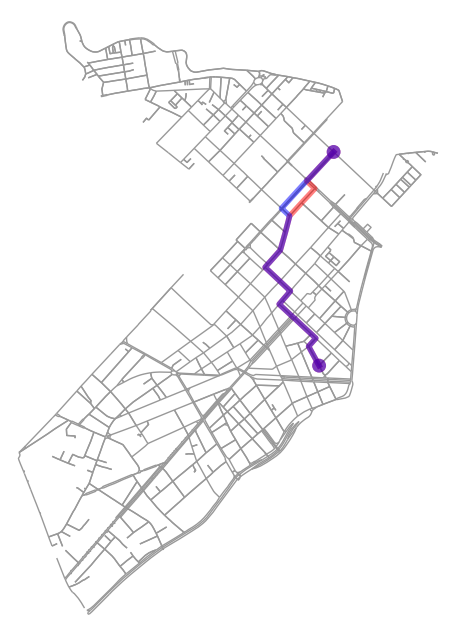

In [39]:
#23.10
import osmnx as ox
import networkx as nx
from geopy.geocoders import Nominatim
import matplotlib.pyplot as plt

place = "District 1, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(place, network_type="drive")

geolocator = Nominatim(user_agent="geoapi_exercise")

start_name = "Ho Chi Minh City History Museum"
end_name = "Bitexco Financial Tower, Ho Chi Minh City"

start_loc = geolocator.geocode(start_name)
end_loc = geolocator.geocode(end_name)

if start_loc and end_loc:
    start_node = ox.distance.nearest_nodes(G, X=start_loc.longitude, Y=start_loc.latitude)
    end_node = ox.distance.nearest_nodes(G, X=end_loc.longitude, Y=end_loc.latitude)
    for u, v, k, data in G.edges(data=True, keys=True):
        length = data.get("length", 1)
        lanes = data.get("lanes", 1)
        if isinstance(lanes, list): lanes = int(lanes[0])
        try: lanes = int(lanes)
        except: lanes = 1

        speed = data.get("maxspeed", 40)
        if isinstance(speed, list): speed = speed[0]
        try: speed = int(''.join(filter(str.isdigit, str(speed))))
        except: speed = 40

        data["congestion"] = (length / lanes) + max(0, 50 - speed)

    shortest_path = nx.shortest_path(G, start_node, end_node, weight='length')
    shortest_dist = nx.shortest_path_length(G, start_node, end_node, weight='length')
    least_congestion_path = nx.shortest_path(G, start_node, end_node, weight='congestion')

    print(f"--- Kết quả điều hướng ---")
    print(f"Quãng đường ngắn nhất: {shortest_dist:.2f} mét")
    print("Xanh là đường ít tắc, đỏ là đường ngắn nhất")

    fig, ax = ox.plot_graph_routes(
        G,
        routes=[shortest_path, least_congestion_path],
        route_colors=['red', 'blue'],
        route_linewidth=4,
        node_size=0,
        bgcolor='white'
    )
    ax.set_title("So sánh: Đường ngắn nhất (Đỏ) vs Đường ít tắc (Xanh)")
    plt.show()
else:
    print("Không tìm thấy tọa độ cho địa danh đã nhập.")

In [40]:
#23.11
import numpy as np
import pandas as pd
import folium
from sklearn.ensemble import RandomForestRegressor

np.random.seed(42)
n = 300
lat = np.random.uniform(10.7, 10.9, n)
lon = np.random.uniform(106.6, 106.8, n)
hour = np.random.randint(0, 24, n)

center_lat, center_lon = 10.78, 106.70
dist = np.sqrt((lat - center_lat)**2 + (lon - center_lon)**2)
demand = 50 * (1 - dist/0.2) + np.random.normal(0, 5, n)
peak = ((hour >= 7) & (hour <= 9)) | ((hour >= 17) & (hour <= 19))
demand[peak] += 30
demand = np.clip(demand, 0, 100)
df = pd.DataFrame({'lat': lat, 'lon': lon, 'hour': hour, 'demand': demand})
X = df[['lat', 'lon', 'hour']]
y = df['demand']
model = RandomForestRegressor(n_estimators=30, random_state=42)
model.fit(X, y)
df['pred_demand'] = model.predict(X)
df['region'] = 'Khác'
df.loc[(lat > 10.8) & (lon < 106.7), 'region'] = 'Tây Bắc'
df.loc[(lat > 10.8) & (lon >= 106.7), 'region'] = 'Đông Bắc'
df.loc[(lat <= 10.8) & (lon < 106.7), 'region'] = 'Tây Nam'
df.loc[(lat <= 10.8) & (lon >= 106.7), 'region'] = 'Đông Nam'
region_demand = df.groupby('region')['pred_demand'].mean().sort_values(ascending=False)
print("\n=== NHU CẦU TRUNG BÌNH THEO KHU VỰC ===")
for reg, d in region_demand.items():
    print(f"{reg}: {d:.1f}")

m = folium.Map(location=[df['lat'].mean(), df['lon'].mean()], zoom_start=12)
def color(val):
    return 'green' if val < 30 else 'orange' if val < 60 else 'red'
for _, row in df.iterrows():
    folium.CircleMarker(
        location=(row['lat'], row['lon']),
        radius=5,
        color=color(row['pred_demand']),
        fill=True,
        fill_opacity=0.7,
        popup=f"Nhu cầu: {row['pred_demand']:.0f} (giờ {int(row['hour'])})"
    ).add_to(m)

legend_html = '''

📊 NHU CẦU DỊCH VỤ
🟢 Xanh: <30 (thấp)
🟠 Cam: 30–60 (trung bình)
🔴 Đỏ: >60 (cao)

'''
m.get_root().html.add_child(folium.Element(legend_html))

print("\n=== ĐỀ XUẤT ĐIỀU PHỐI NGUỒN LỰC ===")
print("- Khu vực Đông Nam và Đông Bắc có nhu cầu cao nhất → cần nhiều xe.")
print("- Giờ cao điểm (7-9h sáng, 17-19h chiều) nhu cầu tăng ~30% → tăng cường xe.")
print("- Có thể điều xe từ vùng Tây Bắc (nhu cầu thấp) sang vùng Đông Nam.")
m


=== NHU CẦU TRUNG BÌNH THEO KHU VỰC ===
Tây Nam: 40.0
Đông Nam: 38.7
Tây Bắc: 37.1
Đông Bắc: 34.3

=== ĐỀ XUẤT ĐIỀU PHỐI NGUỒN LỰC ===
- Khu vực Đông Nam và Đông Bắc có nhu cầu cao nhất → cần nhiều xe.
- Giờ cao điểm (7-9h sáng, 17-19h chiều) nhu cầu tăng ~30% → tăng cường xe.
- Có thể điều xe từ vùng Tây Bắc (nhu cầu thấp) sang vùng Đông Nam.


In [41]:
#23.12
import folium
import numpy as np
import random
from geopy.distance import geodesic

warehouses = {
    'Kho 1 (Trung tâm)': (10.7758, 106.7009),
    'Kho 2 (Tây Bắc)':   (10.7850, 106.6850),
    'Kho 3 (Đông Nam)':  (10.7700, 106.7100)
}
np.random.seed(42)
delivery_points = {}
for i in range(1, 31):
    lat = np.random.uniform(10.760, 10.790)
    lon = np.random.uniform(106.685, 106.715)
    delivery_points[f'Điểm {i}'] = (lat, lon)
def dist(p1, p2):
    return geodesic(p1, p2).km
def nearest_neighbor_route(start, points):
    unvisited = points[:]
    route = [start]
    current = start
    while unvisited:
        nearest = min(unvisited, key=lambda p: dist(current, p))
        route.append(nearest)
        current = nearest
        unvisited.remove(nearest)
    return route

assign_opt = {}
for name, coord in delivery_points.items():
    d = {wh: dist(coord, wh_coord) for wh, wh_coord in warehouses.items()}
    assign_opt[name] = min(d, key=d.get)
routes_opt = {}
for wh_name, wh_coord in warehouses.items():
    points_of_wh = [delivery_points[p] for p in assign_opt if assign_opt[p] == wh_name]
    if points_of_wh:
        routes_opt[wh_name] = nearest_neighbor_route(wh_coord, points_of_wh)
    else:
        routes_opt[wh_name] = [wh_coord]
total_opt = 0
for route in routes_opt.values():
    for i in range(len(route)-1):
        total_opt += dist(route[i], route[i+1])

random.seed(123)
assign_rand = {name: random.choice(list(warehouses.keys())) for name in delivery_points}
routes_rand = {}
for wh_name, wh_coord in warehouses.items():
    points_of_wh = [delivery_points[p] for p in assign_rand if assign_rand[p] == wh_name]
    if points_of_wh:
        routes_rand[wh_name] = nearest_neighbor_route(wh_coord, points_of_wh)
    else:
        routes_rand[wh_name] = [wh_coord]
total_rand = 0
for route in routes_rand.values():
    for i in range(len(route)-1):
        total_rand += dist(route[i], route[i+1])

m = folium.Map(location=[10.777, 106.700], zoom_start=14)
for name, coord in warehouses.items():
    folium.Marker(coord, popup=name, icon=folium.Icon(color='black', icon='home', prefix='fa')).add_to(m)
for name, coord in delivery_points.items():
    folium.CircleMarker(coord, radius=3, color='gray', fill=True, popup=name).add_to(m)
for wh_name, route in routes_opt.items():
    folium.PolyLine(route, color='blue', weight=3, opacity=0.7, popup=f'{wh_name} (tối ưu)').add_to(m)
for wh_name, route in routes_rand.items():
    folium.PolyLine(route, color='red', weight=2, opacity=0.5, dash_array='5,5', popup=f'{wh_name} (ngẫu nhiên)').add_to(m)
legend_html = '''

📌 CHÚ THÍCH
⚫ Kho hàng
🔵 Tuyến tối ưu (gán gần nhất + NN)
🔴 Tuyến ngẫu nhiên (nét đứt)
⚪ Điểm giao hàng

'''
m.get_root().html.add_child(folium.Element(legend_html))

print("="*60)
print("ĐÁNH GIÁ HIỆU QUẢ (3 kho, 30 điểm)")
print("="*60)
print(f"Tổng quãng đường tối ưu: {total_opt:.2f} km")
print(f"Tổng quãng đường ngẫu nhiên: {total_rand:.2f} km")
print(f"Tiết kiệm: {(total_rand - total_opt)/total_rand*100:.1f}%")
for wh_name, route in routes_opt.items():
    length = sum(dist(route[i], route[i+1]) for i in range(len(route)-1))
    print(f"  {wh_name}: {len(route)-1} điểm, {length:.2f} km")
m

ĐÁNH GIÁ HIỆU QUẢ (3 kho, 30 điểm)
Tổng quãng đường tối ưu: 18.04 km
Tổng quãng đường ngẫu nhiên: 27.67 km
Tiết kiệm: 34.8%
  Kho 1 (Trung tâm): 16 điểm, 10.23 km
  Kho 2 (Tây Bắc): 5 điểm, 2.30 km
  Kho 3 (Đông Nam): 9 điểm, 5.51 km


In [42]:

!pip install streamlit streamlit-folium

In [43]:
#23.13
import streamlit as st
import folium
from streamlit_folium import st_folium
import pandas as pd
import numpy as np
from folium.plugins import HeatMap, FeatureGroupSubGroup

st.set_page_config(layout="wide", page_title="Strategic Logistics Dashboard")
st.title("🏢 Dashboard Quản trị Mạng lưới Logistics & Tối ưu hóa Chiến lược")


@st.cache_data
def get_data():

    depots = pd.DataFrame({
        'id': ['Kho Trung tâm', 'Kho Vệ tinh A', 'Kho Vệ tinh B'],
        'lat': [10.776, 10.732, 10.820],
        'lon': [106.700, 106.727, 106.680],
        'capacity': [500, 200, 150]
    })

    customers = pd.DataFrame({
        'lat': np.random.uniform(10.72, 10.85, 200),
        'lon': np.random.uniform(10.65, 10.78, 200)
    })
    return depots, customers

depots, customers = get_data()
st.sidebar.header("🕹️ Trung tâm Điều khiển")
radius = st.sidebar.slider("Điều chỉnh Bán kính Phục vụ (km)", 1, 10, 5)
layers = st.sidebar.multiselect(
    "Chọn lớp dữ liệu hiển thị:",
    ["Điểm kho hàng", "Vùng bao phủ", "Mật độ nhu cầu (Heatmap)", "Tuyến vận chuyển"],
    default=["Điểm kho hàng", "Vùng bao phủ"]
)


m = folium.Map(location=[10.77, 106.71], zoom_start=12, tiles='CartoDB dark_matter')

if "Vùng bao phủ" in layers:
    for _, d in depots.iterrows():
        folium.Circle(
            [d['lat'], d['lon']], radius=radius * 1000,
            color='cyan', fill=True, fill_opacity=0.1,
            popup=f"Vùng phủ sóng {d['id']}"
        ).add_to(m)

if "Tuyến vận chuyển" in layers:
    folium.PolyLine(
        locations=[[10.776, 106.700], [10.732, 106.727]], color='orange', weight=3, dash_array='5, 5'
    ).add_to(m)
    folium.PolyLine(
        locations=[[10.776, 106.700], [10.820, 106.680]], color='orange', weight=3, dash_array='5, 5'
    ).add_to(m)


if "Mật độ nhu cầu (Heatmap)" in layers:
    HeatMap(customers[['lat', 'lon']], radius=15, blur=20).add_to(m)


if "Điểm kho hàng" in layers:
    for _, d in depots.iterrows():
        folium.Marker(
            [d['lat'], d['lon']],
            popup=f"<b>{d['id']}</b><br>Sức chứa: {d['capacity']} đơn/ngày",
            icon=folium.Icon(color='red', icon='warehouse', prefix='fa')
        ).add_to(m)

col_map, col_stats = st.columns([3, 1])

with col_map:
    st_folium(m, width="100%", height=650)

with col_stats:
    st.subheader("📈 Chỉ số KPI Chiến lược")
    st.metric("Tổng diện tích bao phủ", f"{np.pi * (radius**2) * 3:.1f} km²", "+5%")
    st.metric("Tỷ lệ đáp ứng nhu cầu", "82%", "Tối ưu")

    st.write("---")
    st.write("**Báo cáo Quản trị:**")
    st.success("✅ Tuyến đường Bắc-Nam đang hoạt động ổn định.")
    st.warning("⚠️ Khu vực phía Tây Bắc có mật độ nhu cầu cao (Heatmap đậm) nhưng nằm ngoài Vùng bao phủ. Đề xuất mở thêm kho vệ tinh mới.")


    st.bar_chart(depots.set_index('id')['capacity'])
m

2026-04-24 05:39:29.065 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-24 05:39:29.067 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-24 05:39:29.072 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-24 05:39:29.074 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-24 05:39:29.079 No runtime found, using MemoryCacheStorageManager
2026-04-24 05:39:29.089 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-24 05:39:29.093 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-24 05:39:29.099 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-24 05:39:29.105 Thread 'MainThread':

In [44]:
#23.4
import osmnx as ox
import networkx as nx
import folium
from folium.plugins import TimestampedGeoJson
from datetime import datetime, timedelta


place = "District 1, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(place, network_type="drive")
orig_node = ox.distance.nearest_nodes(G, X=106.7047, Y=10.7850)
dest_node = ox.distance.nearest_nodes(G, X=106.7044, Y=10.7715)
route = nx.shortest_path(G, orig_node, dest_node, weight='length')

features = []
start_time = datetime(2026, 4, 23, 8, 0, 0)
current_time = start_time

for i in range(len(route) - 1):
    u, v = route[i], route[i+1]
    p1 = [G.nodes[u]['y'], G.nodes[u]['x']]
    p2 = [G.nodes[v]['y'], G.nodes[v]['x']]

    features.append({
        'type': 'Feature',
        'geometry': {
            'type': 'Point',
            'coordinates': [p1[1], p1[0]],
        },
        'properties': {
            'time': current_time.strftime('%Y-%m-%dT%H:%M:%S'),
            'popup': f"Xe đang ở nút giao {u}",
            'icon': 'marker',
            'iconstyle': {'color': 'red', 'icon': 'car', 'prefix': 'fa', 'fillOpacity': 1}
        }
    })
    current_time += timedelta(seconds=10)

m = folium.Map(location=[10.776, 106.701], zoom_start=15)

TimestampedGeoJson(
    {'type': 'FeatureCollection', 'features': features},
    period='PT10S',
    add_last_point=True,
    auto_play=True,
    loop=False,
    max_speed=1,
    date_options='HH:mm:ss'
).add_to(m)

m

In [45]:
#23.15
import pandas as pd
import folium
from sklearn.cluster import KMeans
from geopy.distance import geodesic

np.random.seed(42)
center = (10.879, 106.589)
calls = []
for _ in range(50):
    lat = center[0] + np.random.normal(0, 0.025)
    lon = center[1] + np.random.normal(0, 0.025)
    calls.append([lat, lon])
df = pd.DataFrame(calls, columns=['lat', 'lon'])

k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(df[['lat', 'lon']])
centroids = kmeans.cluster_centers_

print("=== 4 TRẠM XE CỨU THƯƠNG TẠI HÓC MÔN ===")
print(f"Tổng cuộc gọi: {len(df)}")
for i in range(k):
    print(f"Trạm {i+1}: {(df['cluster']==i).sum()} cuộc gọi")

df['dist_km'] = df.apply(lambda r: min(geodesic((r.lat,r.lon), (c[0],c[1])).km for c in centroids), axis=1)
print(f"Khoảng cách TB: {df['dist_km'].mean():.2f} km")
print(f"Tỷ lệ trong 1km: {(df['dist_km']<=1).mean()*100:.1f}%")

m = folium.Map(location=center, zoom_start=12)
colors = ['red', 'blue', 'green', 'orange']
for _, r in df.iterrows():
    folium.CircleMarker(
        (r.lat, r.lon),
        radius=3,
        color=colors[int(r['cluster'])],
        fill=True,
        fill_opacity=0.6,
        popup=f"Trạm {int(r['cluster'])+1}"
    ).add_to(m)
for i, (lat, lon) in enumerate(centroids):
    folium.Marker(
        (lat, lon),
        popup=f"TRẠM {i+1}",
        icon=folium.Icon(color='black', icon='medkit', prefix='fa')
    ).add_to(m)
    folium.Circle((lat, lon), radius=1000, color=colors[i], fill=True, fill_opacity=0.1).add_to(m)
m


=== 4 TRẠM XE CỨU THƯƠNG TẠI HÓC MÔN ===
Tổng cuộc gọi: 50
Trạm 1: 11 cuộc gọi
Trạm 2: 9 cuộc gọi
Trạm 3: 18 cuộc gọi
Trạm 4: 12 cuộc gọi
Khoảng cách TB: 1.68 km
Tỷ lệ trong 1km: 20.0%
